In [1]:
import torch
from snntorch import functional as SF

from thesis_code.datasets import get_SHD_dataloader
from thesis_code.networks import train, test, models
from thesis_code.plotting import plot_performance

c:\Users\emiel\Documents\Study\Thesis\Thesis-Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [6]:
SHD_trainloader, input_dim, classes = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=True,
    shuffle=True,
    re_download=False,
)

SHD_testloader, _, _ = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=False,
    shuffle=True,
    re_download=False,
)

net = models.SimpleSRNN(
    n_in=input_dim,
    ns_hidden=[1000],
    n_out=len(classes),
    beta=0.9,
).to(device)

Test Accuracy before training is: 0.04726148409893993


Epoch 0:   2%|▏         | 1/64 [00:01<01:40,  1.60s/it, acc=3.91%, loss=7.51]

Epoch 0, Iteration 0 — Loss: 7.51, Acc: 3.91%


Epoch 0:  41%|████      | 26/64 [00:37<00:54,  1.42s/it, acc=4.69%, loss=3.10] 

Epoch 0, Iteration 25 — Loss: 3.10, Acc: 4.69%


Epoch 0:  80%|███████▉  | 51/64 [01:13<00:20,  1.55s/it, acc=5.47%, loss=2.88] 

Epoch 0, Iteration 50 — Loss: 2.88, Acc: 5.47%


Epoch 0: 100%|██████████| 64/64 [01:31<00:00,  1.43s/it, acc=5.43%, loss=2.78]


Test Accuracy after training is: 0.06537102473498234


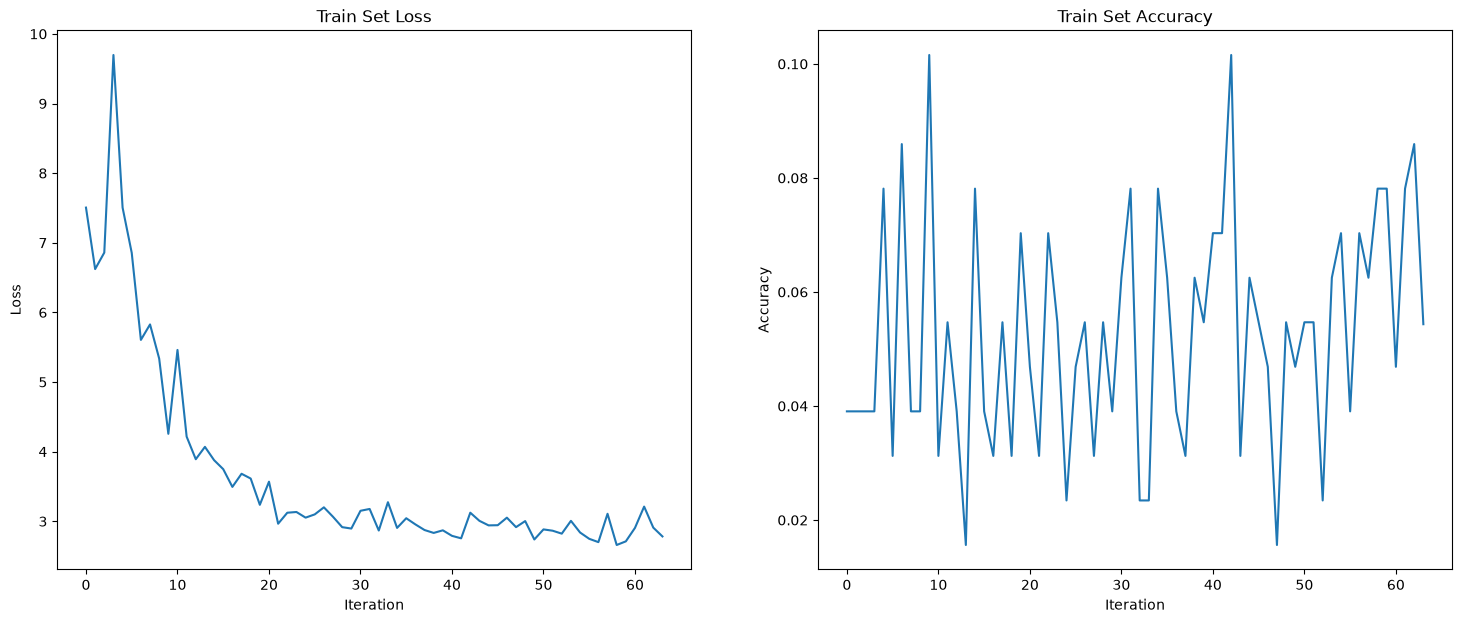

In [8]:
accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    optimizer=torch.optim.Adam(net.parameters(), lr=2e-2, betas=(0.9, 0.999)),
    loss_fn=SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2),
    loss_is_membrane=False,
    n_epochs=1,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")